In [85]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as plt
from sklearn import tree
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [2]:
# trasform the csv file to a dataframe 
df = pd.read_csv('C:/Users/ISHMO_CT/Desktop/projects/Loan_ML/Data/loan_data [Task 1-3] - loan_data.csv')

In [3]:
# print the first five rows of the data
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
# drop the Loan Id columns because it is unque throught so it won't help us in our model
# or we can make it an index 
df = df.set_index('Loan_ID')
df.head(3)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
Loan_ID,,,,,,,,,,,,
LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y


In [23]:
# split the data into target and features 
target = 'Loan_Status'
y = df[target]
X = df.drop(columns=target)

In [24]:
# To esnure we have splitted our data the right way I print the shapes of target and features 
print(y.shape)
print(X.shape)

(614,)
(614, 11)


TASK 1


1a. Separate the data into training and test sets (use random_state=42 in the train_test_split for reproducibility).


In [25]:
# split the data into test and train set 
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
# print out the shapes to make sure I have splitted the datset right 
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(491, 11)
(491,)
(123, 11)
(123,)


In [27]:
# I will first clean the data 
# I diplayed the datatypes for the columns 
df.dtypes

Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

In [28]:
# According to the dependets the column in the df should be numeric (number int)
# however when we display it it says it is an object
# Lets display the unique or value counts to find iut what is causing it
df['Dependents'].value_counts()

# According to the diction this is number of depedants and this is an ordinal column so 
# The + is on 3 turns the column in to datatype of objet I will not change because it change the meaning
# # 3+ means the the loaner has either 3 or morethan so I will treat this as an ordinal columns and transform it

Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64

1b. Create a model pipeline (for feature transformations)

In [ ]:
# Odentiify different datatypes in the dataframe and create trsnfrmation Pipeline 
# identify ordinal columns in features
ordinal_features = ['Dependents']
# define a transformation Pipeline for the ordinal features 
ordinal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder())
])

# Identify categorical columns
nominal_features = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', ]
#define transformation pipeline for the categorical features
nominal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value="MISSING")),
    ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Identify numerical columns 
numerical_features = ['Credit_History', 'Loan_Amount_Term', 'LoanAmount', 'CoapplicantIncome', 'ApplicantIncome']
# Define the tranformation pipeline for the numerical features
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])


In [32]:
# I created a columns tranfromer to inlcude all my pipelines tuples 
column_transformer = ColumnTransformer(transformers=[
    ('ordinal', ordinal_pipeline, ordinal_features),
    ('nominal', nominal_pipeline, nominal_features),
    ('numeric', numerical_pipeline, numerical_features)
])

In [38]:
# I create the final model pipeline to including instatiating the model
dt_default_pipeline = Pipeline(steps=[
    ('processors', column_transformer),
    ('dt_classifier', DecisionTreeClassifier())
])

dt_default_pipeline.fit(X_train, y_train)

Pipeline(steps=[('processors',
                 ColumnTransformer(transformers=[('ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder())]),
                                                  ['Dependents']),
                                                 ('nominal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='MISSING',
                                                                                 strategy='constant')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Gender', 'Married',
                                                   'Education', 'Self_Employed',
                                                   'Property_Area']),
                                                 ('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Credit_History',
                                                   'Loan_Amount_Term',
                                                   'LoanAmount',
                                                   'CoapplicantIncome',
                                                   'ApplicantIncome'])])),
                ('dt_classifier', DecisionTreeClassifier())])

In [42]:
# Lets have look at our transformed data before it was trained 
X_train_transformed = dt_default_pipeline.named_steps['processors'].transform(X_train)
# Convert the transformed features to a DataFrame with appropriate column names
X_train_transformed_dt = pd.DataFrame(X_train_transformed, columns=dt_default_pipeline.named_steps['processors'].get_feature_names_out())
# View the transformed data
X_train_transformed_dt.head()

,ordinal__Dependents,nominal__Gender_Female,nominal__Gender_MISSING,nominal__Gender_Male,nominal__Married_MISSING,nominal__Married_No,nominal__Married_Yes,nominal__Education_Graduate,nominal__Education_Not Graduate,nominal__Self_Employed_MISSING,nominal__Self_Employed_No,nominal__Self_Employed_Yes,nominal__Property_Area_Rural,nominal__Property_Area_Semiurban,nominal__Property_Area_Urban,numeric__Credit_History,numeric__Loan_Amount_Term,numeric__LoanAmount,numeric__CoapplicantIncome,numeric__ApplicantIncome
0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,3.199099e-16,0.295122,1.349134,0.180667,0.083915
1,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,4.472383e-01,0.295122,-0.205624,0.385430,-0.429338
2,2.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,4.472383e-01,0.295122,0.710987,0.005831,0.126095
3,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,4.472383e-01,0.295122,-0.240432,0.464185,-0.576970
4,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,-2.434254e+00,0.295122,-0.588512,-0.528127,-0.225522


In [35]:
# lets print the shape to confirm we are using tht right train set 
X_train_transformed_dt.shape

(491, 20)

1. Start by building and evaluating a default decision tree model using appropriate metrics and a confusion matrix.

In [47]:
# Lets me evaluate the model 
# We start by testing the model 
#I realized we don't need to column transform the X_test set because the pipline with the model will do it for us


In [48]:
# Then now I can test model 
# I will test the default model using the test set 
# default_test_pred =  dt_default_pipeline.predict(X_test_transformed)
default_test_pred =  dt_default_pipeline.predict(X_test)
default_test_pred

array(['Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'N', 'N', 'Y', 'N', 'Y', 'N',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'N', 'Y', 'N', 'Y', 'N', 'Y',
       'N', 'Y', 'Y', 'N', 'N', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'N', 'N', 'N', 'N', 'Y', 'Y',
       'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'N', 'Y', 'N', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y',
       'N', 'Y', 'N', 'Y', 'Y', 'Y', 'N', 'N', 'Y', 'N', 'Y', 'Y', 'Y',
       'N', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'N',
       'Y', 'N', 'Y', 'N', 'Y', 'Y', 'Y', 'N', 'N', 'Y', 'N', 'Y', 'Y',
       'Y', 'N', 'N', 'Y', 'Y', 'N'], dtype=object)

In [49]:
# Lets me now evaluate the default model using classification report  and confusion matrix
# Let me start with classification report 
# Here I am comparing the actual test values with what the model predicted 
print(classification_report(y_test, default_test_pred))

              precision    recall  f1-score   support

           N       0.51      0.49      0.50        43
           Y       0.73      0.75      0.74        80

    accuracy                           0.66       123
   macro avg       0.62      0.62      0.62       123
weighted avg       0.65      0.66      0.66       123



In [50]:
# Then I print out the confusion_matrix still in comparison of the actual test sest target values and what the model predicted
confusion_matrix(y_test, default_test_pred)

array([[21, 22],
       [20, 60]])

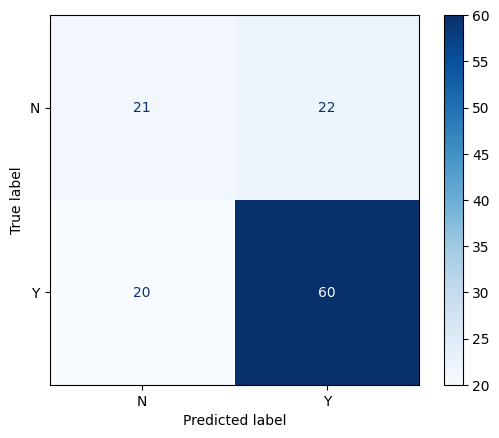

In [51]:
# let me now display it the cinfusion matrix in image form
ConfusionMatrixDisplay.from_predictions(y_test, default_test_pred, cmap="Blues")

Task1. 2. Then, use GridSearchCV to tune the model. Be sure to change the default scoring to "recall_macro" when you instantiate the GridSearch.  (Be sure to explain the GridSearchCV technique)

Grid Search Cross-Validation (GridSearchCV) is a hyperparameter tuning technique in machine learning that helps find the best combination of hyperparameters for a model by exhaustively searching through a specified parameter grid. It evaluates a model's performance for each combination of parameters, typically using cross-validation to get an unbiased estimate of performance.


In [57]:
# Before I instatiate the Grid search 
# I don't need to instatiate the model again since I already have we shall use the original model
# I need to define a dictionary of parameters (hyperparameters) to be used in the GridSearchCV


# parameters for tuning 
param_grid = {
    'dt_classifier__criterion': ['gini', 'entropy'],
    'dt_classifier__max_depth': [3, 5, 10, None],
    'dt_classifier__min_samples_split': [2, 5, 10],
    'dt_classifier__min_samples_leaf': [1, 2, 4]
}

In [58]:
#lets instatiate the grid search cv to tune model
# The Grid search cv has different attributes
# DecisionTreeClassifier(criterion='gini', max_depth=3, min_samples_split=2)
grid_search = GridSearchCV(
    estimator=dt_default_pipeline,      # atrribute for the model tobe used
    param_grid=param_grid,   #attribute for thr parameters to tune the model with different values
    scoring="recall_macro",  # scoring metrics (Actually good for imbalanced malticlass problems)
    cv=5,                    # cross validation (we are using 5 here)
    verbose=1,               # to diplay the progress
    n_jobs=-1,               # to utelize all my cpu cores 
    return_train_score=True  # store training scores in cv results
)

In [59]:
# Lets fit the the data with the model 
# I am going to use my x training data set transformed data 
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('processors',
                                        ColumnTransformer(transformers=[('ordinal',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OrdinalEncoder())]),
                                                                         ['Dependents']),
                                                                        ('nominal',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(fill_value='MISSING',
                                                                                                        strategy='constant')),
                                                                                         ('ohe',
                                                                                          OneHotEncoder(handle_unknown='ig...
                                                                          'LoanAmount',
                                                                          'CoapplicantIncome',
                                                                          'ApplicantIncome'])])),
                                       ('dt_classifier',
                                        DecisionTreeClassifier())]),
             n_jobs=-1,
             param_grid={'dt_classifier__criterion': ['gini', 'entropy'],
                         'dt_classifier__max_depth': [3, 5, 10, None],
                         'dt_classifier__min_samples_leaf': [1, 2, 4],
                         'dt_classifier__min_samples_split': [2, 5, 10]},
             return_train_score=True, scoring='recall_macro', verbose=1)

In [60]:
# I found out best model from grid search
best_model = grid_search.best_estimator_
best_model

Pipeline(steps=[('processors',
                 ColumnTransformer(transformers=[('ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder())]),
                                                  ['Dependents']),
                                                 ('nominal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='MISSING',
                                                                                 strategy='constant')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Gender', 'Married',
                                                   'Education', 'Self_Employed',
                                                   'Property_Area']),
                                                 ('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Credit_History',
                                                   'Loan_Amount_Term',
                                                   'LoanAmount',
                                                   'CoapplicantIncome',
                                                   'ApplicantIncome'])])),
                ('dt_classifier',
                 DecisionTreeClassifier(max_depth=3, min_samples_leaf=2))])

Task 1, 3. Visualize the trees from both the default and the tuned model versions.

In [ ]:
# before I visualise I need to find the featire names for the x_train that was transformed
# rememeber that in our pipeline we used column tranformer to encode feature so more columns were created
# start by grabbing the column transformer 
transformed_columns = []
ct = dt_default_pipeline.named_steps['processors']

# use a loop to loop through our pipeline step for trnsforming data 
for name, transformer, columns in ct.transformers_:
    if name == 'remainder':
        continue  
    if hasattr(transformer, 'get_feature_names_out'):
        names = transformer.get_feature_names_out(columns)
    else:
        names = columns
    transformed_columns.extend(names)
transformed_columns

['Dependents',
 'Gender_Female',
 'Gender_MISSING',
 'Gender_Male',
 'Married_MISSING',
 'Married_No',
 'Married_Yes',
 'Education_Graduate',
 'Education_Not Graduate',
 'Self_Employed_MISSING',
 'Self_Employed_No',
 'Self_Employed_Yes',
 'Property_Area_Rural',
 'Property_Area_Semiurban',
 'Property_Area_Urban',
 'Credit_History',
 'Loan_Amount_Term',
 'LoanAmount',
 'CoapplicantIncome',
 'ApplicantIncome']

c:\Users\ISHMO_CT\.virtualenvs\Loan_ML-N0COh43c\Lib\site-packages\sklearn\tree\_export.py:386: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  class_name = self.class_names[np.argmax(value)]


[Text(0.44097699175824173, 0.9705882352941176, 'Credit_History <= -1.217\ngini = 0.423\nsamples = 491\nvalue = [149, 342]\nclass = Y'),
 Text(0.08241758241758242, 0.9117647058823529, 'CoapplicantIncome <= 2.028\ngini = 0.157\nsamples = 70\nvalue = [64, 6]\nclass = N'),
 Text(0.26169728708791207, 0.9411764705882353, 'True  '),
 Text(0.054945054945054944, 0.8529411764705882, 'ApplicantIncome <= -0.2\ngini = 0.136\nsamples = 68\nvalue = [63, 5]\nclass = N'),
 Text(0.03296703296703297, 0.7941176470588235, 'Loan_Amount_Term <= -1.501\ngini = 0.045\nsamples = 43\nvalue = [42, 1]\nclass = N'),
 Text(0.02197802197802198, 0.7352941176470589, 'ApplicantIncome <= -0.499\ngini = 0.245\nsamples = 7\nvalue = [6, 1]\nclass = N'),
 Text(0.01098901098901099, 0.6764705882352942, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]\nclass = Y'),
 Text(0.03296703296703297, 0.6764705882352942, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]\nclass = N'),
 Text(0.04395604395604396, 0.7352941176470589, 'gini = 0.0\nsamples = 3

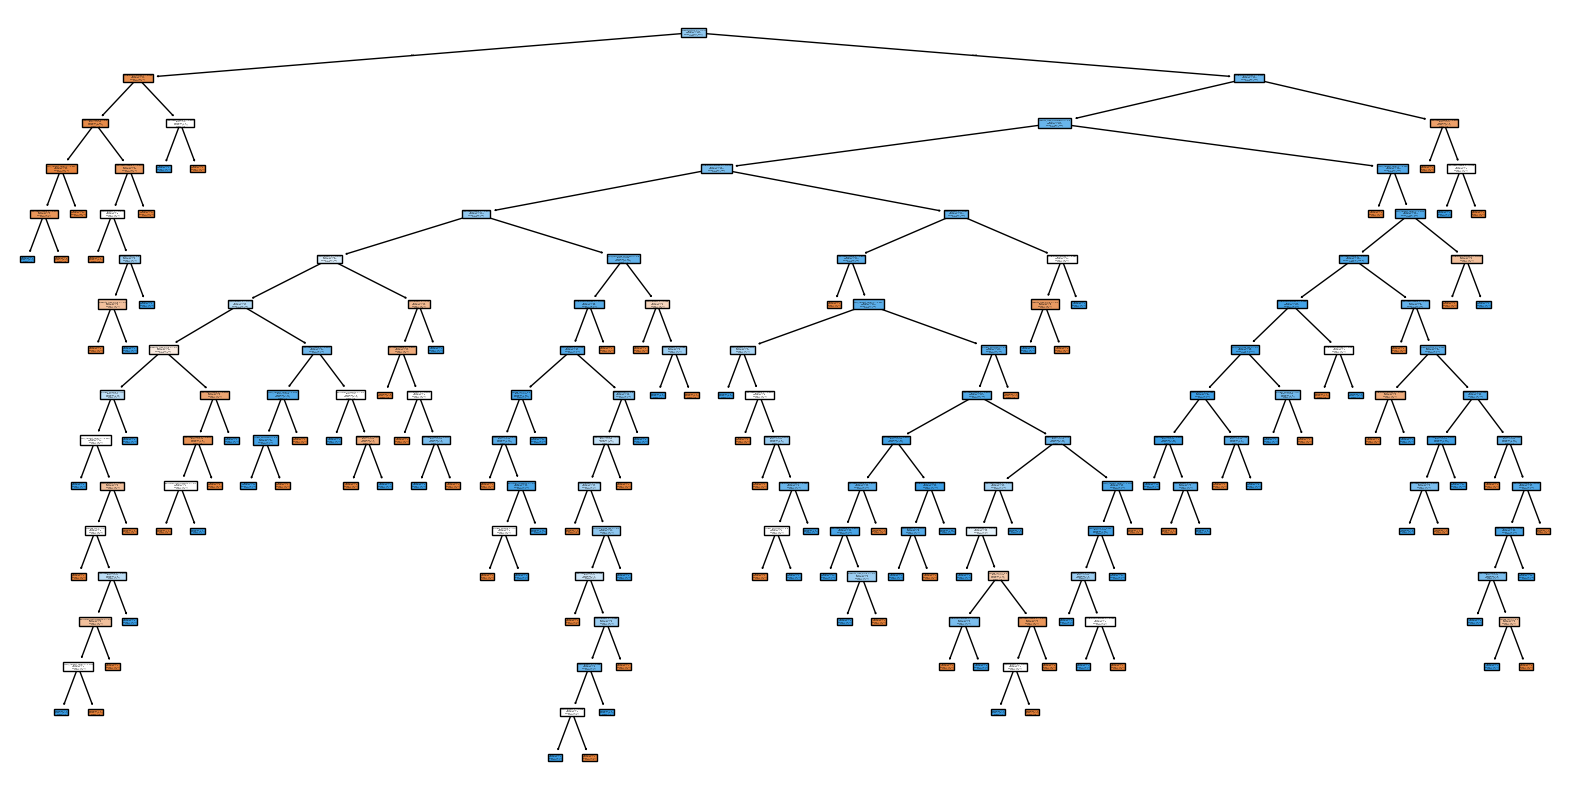

In [ ]:
# here am visualizing the default model 
# I will still need to use model in the Pipeline .named_steps["name"] comes in handy 
plt.figure(figsize=(20,10))
tree.plot_tree(dt_default_pipeline.named_steps['dt_classifier'], feature_names=transformed_columns, class_names=y_train, filled=True)

c:\Users\ISHMO_CT\.virtualenvs\Loan_ML-N0COh43c\Lib\site-packages\sklearn\tree\_export.py:386: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  class_name = self.class_names[np.argmax(value)]


[Text(0.4583333333333333, 0.875, 'Credit_History <= -1.217\ngini = 0.423\nsamples = 491\nvalue = [149, 342]\nclass = Y'),
 Text(0.25, 0.625, 'CoapplicantIncome <= 2.028\ngini = 0.157\nsamples = 70\nvalue = [64, 6]\nclass = N'),
 Text(0.35416666666666663, 0.75, 'True  '),
 Text(0.16666666666666666, 0.375, 'ApplicantIncome <= -0.2\ngini = 0.136\nsamples = 68\nvalue = [63, 5]\nclass = N'),
 Text(0.08333333333333333, 0.125, 'gini = 0.045\nsamples = 43\nvalue = [42, 1]\nclass = N'),
 Text(0.25, 0.125, 'gini = 0.269\nsamples = 25\nvalue = [21, 4]\nclass = N'),
 Text(0.3333333333333333, 0.375, 'gini = 0.5\nsamples = 2\nvalue = [1, 1]\nclass = N'),
 Text(0.6666666666666666, 0.625, 'CoapplicantIncome <= 2.512\ngini = 0.322\nsamples = 421\nvalue = [85, 336]\nclass = Y'),
 Text(0.5625, 0.75, '  False'),
 Text(0.5, 0.375, 'Property_Area_Semiurban <= 0.5\ngini = 0.314\nsamples = 416\nvalue = [81, 335]\nclass = Y'),
 Text(0.4166666666666667, 0.125, 'gini = 0.369\nsamples = 250\nvalue = [61, 189]\ncl

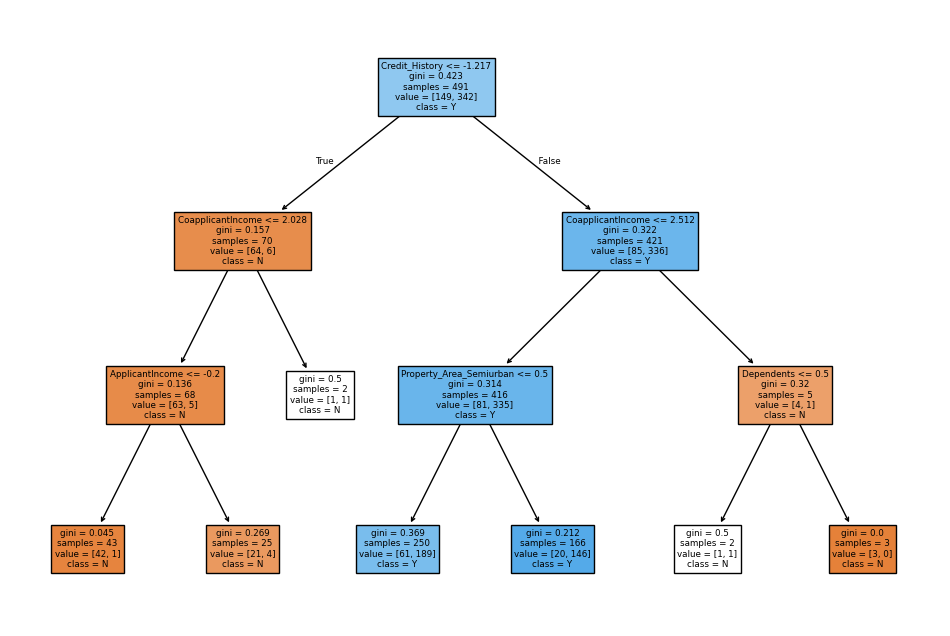

In [ ]:
# Here I am visualizing the best model from the grid search view best model
plt.figure(figsize=(12,8))
tree.plot_tree(best_model.named_steps['dt_classifier'], feature_names=transformed_columns, class_names=y_train,  filled=True)

Task 1. 4.Make sure you have evaluated both the default and the tuned versions using appropriate metrics and a confusion matrix.

In [77]:
# I have already evaluated the default model model 
# here I am going to evaluate the tuned version (best model)
# I will start by predicting using the best model 
best_model_pred = best_model.predict(X_test)
best_model_pred

array(['Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'N', 'N', 'Y', 'Y',
       'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'N', 'Y', 'N', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'N',
       'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y',
       'N', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'N', 'Y', 'N', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y'], dtype=object)

In [78]:
# Then now evaluate the version model  using the actual target values of test set and the values predicted by the tuned model
# using confusion report
print(classification_report(y_test, best_model_pred))

              precision    recall  f1-score   support

           N       0.95      0.42      0.58        43
           Y       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



In [79]:
# Let me display the confusion matrix 
confusion_matrix(y_test, best_model_pred)

array([[18, 25],
       [ 1, 79]])

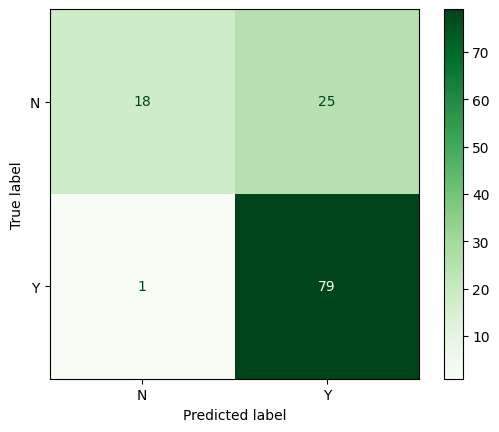

In [80]:
# let me display the confusion matrix 
ConfusionMatrixDisplay.from_predictions(y_test, best_model_pred, cmap="Greens")

Task1. 5.Which combination of hyperparameters led to the best-tuned model?

In [81]:
# to find the best parameters in the grid search that made the best tuned model we will use  .best_params_ 
print("Best Hyperparameters:", grid_search.best_params_)

Best Hyperparameters: {'dt_classifier__criterion': 'gini', 'dt_classifier__max_depth': 3, 'dt_classifier__min_samples_leaf': 2, 'dt_classifier__min_samples_split': 2}


In [82]:
# best_param = {
#     'criterion': 'entropy', 
#     'max_depth': 10, 
#     'max_leaf_nodes': 10, 
#     'min_samples_leaf': 2, 
#     'min_samples_split': 5
# }

Task 2- SVM Algorithm
From first principles, explain the SVM algorithm, highlight the pros and cons of this algorithm.

This is how I understood SVM. 
SVM a supervised machine learning algorithm used for classification (and sometimes regression).
It finds the best boundary (hyperplane) that separates data points of different classes.


### In lay man terms
Lets say I have two types of fruits carrots and apples
I will use the size and color to differeciate them.
I will arrange them in way acording sizes ofcourse carrots are abit long so they will find them selves on one side and the apples on the other. Then I draw a line (hyperplane) between them. 


The same way SVM finds the best possible boundary (called a hyperplane) that splits the apples from the carrots, with the most space (margin) on both sides.


I used a line to separate them however in this case this more than a line that is why there is word hyperplane in brackets.
When the line is drawn a certain distance is measured to stay as far away from both groups (carrots and apples) as possible.
That distance is defined support vectors. The suppot vectors define how far away the line should go 


Here is the link to my drawing to illustrate it 
https://drive.google.com/file/d/1tAn4NCccYUqw7XP5Xsxqe3m2PyywGwYn/view?usp=sharing


### Mathematically here is the explanation

Assume we have:

- A dataset with two features: (color) `x₁` and size `x₂`
- Two classes labeled as: (carrot) `y = +1` and (apples)`y = -1`

wᵀx + b = 0
Where:

- `w` is the **weight vector**
- `b` is the **bias** (a constant that shifts the hyperplane)
- `x` is the **input vector** (a data point)

This equation represents the decision boundary that separates the two classes.

##  Pros of Support Vector Machines (SVM)

| Feature                          | Explanation                                                                 |
|----------------------------------|-----------------------------------------------------------------------------|
| **Effective in high-dimensional spaces** | Works well when number of features greater than number of samples (e.g., text classification, gene expression). |
| **Robust to overfitting**       | Maximizing the margin helps generalize well with proper regularization.     |
| **Performs well with clear margin** | Excellent performance when the data is clearly separable.                |
| **Flexible with Kernels**       | Supports linear, polynomial, RBF, and custom kernels to handle non-linearity. |
| **Sparse support vectors**      | Only support vectors affect the decision function, making it memory efficient in some cases. |

##  Cons of Support Vector Machines (SVM)

| Feature                          | Explanation                                                                 |
|----------------------------------|-----------------------------------------------------------------------------|
| **Computationally expensive**   | Slow training on large datasets (complexity up to O(n³)).                    |
| **Hard to tune**                | Choosing the right kernel, C, and gamma can be tricky and needs cross-validation. |
| **Sensitive to outliers**       | Outliers can distort the margin and affect model performance.               |
| **Poor performance with overlapping classes** | Struggles when classes are not well separated.                         |
| **Not easily interpretable**    | Difficult to explain the model, especially with non-linear kernels.         |




Task 2a. Build an SVM classifier
Separate the data into training and test sets (use random_state=42 in the train_test_split for reproducibility).


In [14]:
X_train, X_test, y_train, y_test  = train_test_split(X, y, test_size=0.2, random_state=42)

Task 2 bCreate a model pipeline (for feature transformations)


In [85]:
# Since I had already created my Pipeline for feature transformation I will use that
# This time I am using SVM model in my Pipeline 
svm_pipeline = Pipeline([
    ('preprocessor', column_transformer),
    ('svm_classifier', SVC())
])

In [ ]:
# Now I trained the model using train set 
# The Pipeline will handle the transformation and model to be used
svm_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder())]),
                                                  ['Dependents']),
                                                 ('nominal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='MISSING',
                                                                                 strategy='constant')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Gender', 'Married',
                                                   'Education', 'Self_Employed',
                                                   'Property_Area']),
                                                 ('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Credit_History',
                                                   'Loan_Amount_Term',
                                                   'LoanAmount',
                                                   'CoapplicantIncome',
                                                   'ApplicantIncome'])])),
                ('svm_classifier', SVC())])

Task 3 Evaluate your model using a classification report and a Confusion Matrix display (SVM MODEL)

In [89]:
# before we evaluate we need to test the model using the test set and get predictions for the test set
# I don't need to worry about transforming the test set since the pipeline has both the model and the column tranformer 
svm_predit = svm_pipeline.predict(X_test)
svm_predit


array(['Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'N', 'N', 'Y', 'Y',
       'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'N', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'N',
       'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y',
       'N', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'N', 'Y', 'N', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'N', 'Y', 'Y'], dtype=object)

In [90]:
# Now I will evaluate the using the the actual target values of the test set and the predictions from the model 
print(classification_report(y_test, svm_predit))

              precision    recall  f1-score   support

           N       0.90      0.42      0.57        43
           Y       0.76      0.97      0.85        80

    accuracy                           0.78       123
   macro avg       0.83      0.70      0.71       123
weighted avg       0.81      0.78      0.75       123



In [91]:
confusion_matrix(y_test, svm_predit)

array([[18, 25],
       [ 2, 78]])

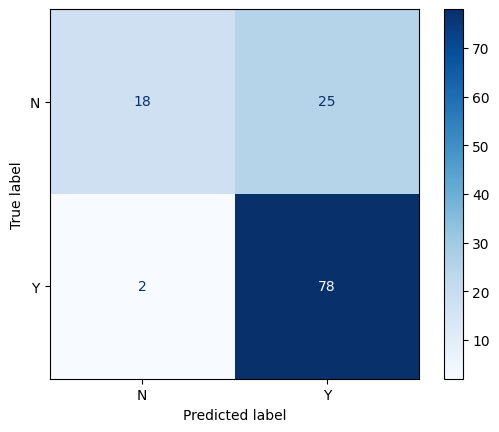

In [94]:
ConfusionMatrixDisplay.from_predictions(y_test, svm_predit, cmap="Blues")

Describe your results.

Y represents Yes (Qualifies for loan)

N represents No (not qualified for loan)
| Metric                  | Value | Explanation                                      |
|-------------------------|-------|--------------------------------------------------|
| **True Negatives (TN)** | 18    | Correctly predicted N                            |
| **False Positives (FP)**| 25    | Predicted Y, but was actually N                  |
| **False Negatives (FN)**| 2     | Predicted N, but was actually Y                  |
| **True Positives (TP)** | 78    | Correctly predicted Y                            |
| **Precision (N)**       | 0.90  | Out of all predicted N, 90% were actually N      |
| **Recall (N)**          | 0.42  | Out of all actual N, only 42% were predicted     |
|                         |       |               |
| **Precision (Y)**       | 0.76  | 76% of predicted Y were correct                  |
| **Recall (Y)**          | 0.97  | Model caught almost all actual Y cases           |
|                         |       | → Only missed 2 out of 80 actual Y instances     |



The SVM model is very good at detecting Y (positive class).

But it struggles abit with class N — it misclassifies many N cases as Y.

This could be due to Class imbalance.
when you look at the data target value count. there is an imbalance.


Task 3 -  Random Forest
From first principles, explain the Random Forest, highlight the pros and cons of this algorithm.


### Random Forest 

is an ensemble machine learning algorithm used for both classification and regression tasks. It's built on top of decision trees, combining the predictions of multiple trees to improve accuracy and robustness.

Let me define decision tree first

A decision tree splits data into branches based on feature values to make predictions.

Random Forest is an ensemble method, meaning it combines several models (trees) to create a stronger one.

Lay man terms

This time let me use our data as an example.


Dream Housing Finance company builds a forest of decision trees — let’s say 10 trees.
Each tree has been trained to make loan decisions using different parts of the data.

Now a new customer walks in — and we want to decide:
"Should this person get a loan?"

Let’s say the customer has:

ApplicantIncome: $40,000

Dependents: 3+

Self_Employed: Yes

LoanAmount: $40000

Gender: M

| Tree    | Looks at...              | Decision |
|---------|--------------------------|----------|
| Tree 1  | ApplicantIncome & Dependents    | Y        |
| Tree 2  | Self_Employed & LoanAmount        | Y        |
| Tree 3  | Gender & ApplicantIncome             | N        |
| Tree 4  | LoanAmount & Gender      | Y        |
| Tree 5  |LoanAmount              | N        |


3 trees say Yes (Y)

2 trees say No (N)

Majority wins → The final decision is Yes → The customer gets the loan!


Mathematically Random forest is denoted by
\[
\hat{y} = \frac{1}{T} \sum_{t=1}^{T} f_t(x)
\]



| Symbol                      | Description                                                  |
|----------------------------|--------------------------------------------------------------|
| \( \hat{f}_{\text{RF}}(x) \) | Final prediction from the Random Forest for input \( x \)     |
| \( T \)                    | Total number of trees in the forest                          |
| \( f_t(x) \)               | Prediction from the \( t^{th} \) decision tree               |
| \( \hat{f}_{\text{RF}}(x) = \frac{1}{T} \sum_{t=1}^{T} f_t(x) \) | Random Forest formula (average of all tree predictions) |


The pros and cons
| Pros                                         | Cons                                               |
|----------------------------------------------|----------------------------------------------------|
| High accuracy and performance                | Slower to predict due to many trees                |
| Reduces overfitting compared to single trees | Less interpretable than individual decision trees  |
| Handles large datasets and high dimensions   | Can be memory-intensive                            |
| Works well with missing or unbalanced data   | Requires tuning for best performance               |
| Estimates feature importance automatically   | May overfit if not properly controlled             |
| Robust to outliers and noise                 | Training can be slower with very large datasets    |




Task 3 2a. Build a Random Forest classifier
Separate the data into training and test sets (use random_state=42 in the train_test_split for reproducibility).


In [104]:
# start by spliting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# print the percatge to make sure we split it right 
train_percentage = (len(X_train) / len(X)) * 100
test_percentage = (len(X_test) / len(X)) * 100
print(f"Training Set Percentage: {train_percentage:.2f}%")
print(f"Test Set Percentage: {test_percentage:.2f}%")

Training Set Percentage: 79.97%
Test Set Percentage: 20.03%


Task 3 b.Create a model pipeline (for feature transformations)


In [106]:
# I build the pipeline using the column_transformer we created to transform the data and new instatiation of the random forest model 
rf_pipeline = Pipeline([
    ('preprocessor', column_transformer),
    ('rf_classifier', RandomForestClassifier())
])

In [107]:
# Now let me train the model 
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder())]),
                                                  ['Dependents']),
                                                 ('nominal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='MISSING',
                                                                                 strategy='constant')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Gender', 'Married',
                                                   'Education', 'Self_Employed',
                                                   'Property_Area']),
                                                 ('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Credit_History',
                                                   'Loan_Amount_Term',
                                                   'LoanAmount',
                                                   'CoapplicantIncome',
                                                   'ApplicantIncome'])])),
                ('rf_classifier', RandomForestClassifier())])

Task 3 3.Evaluate your model using a classification report and a Confusion Matrix display.

In [109]:
# Before I evaluate I will have to first predict for test set using the model
# The Pipeline already has the column tranformation so test set will be transformed 
rf_model_predict = rf_pipeline.predict(X_test)


In [110]:
# in my evaluation lets start with classification_report
# Here I am comparing the actual test values and what the model has predicted 
print(classification_report(y_test, rf_model_predict))

              precision    recall  f1-score   support

           N       0.78      0.42      0.55        43
           Y       0.75      0.94      0.83        80

    accuracy                           0.76       123
   macro avg       0.77      0.68      0.69       123
weighted avg       0.76      0.76      0.73       123



In [ ]:
# Here I am findin out the True positive the False positive and their negatives  
confusion_matrix(y_test, rf_model_predict)

array([[18, 25],
       [ 5, 75]])

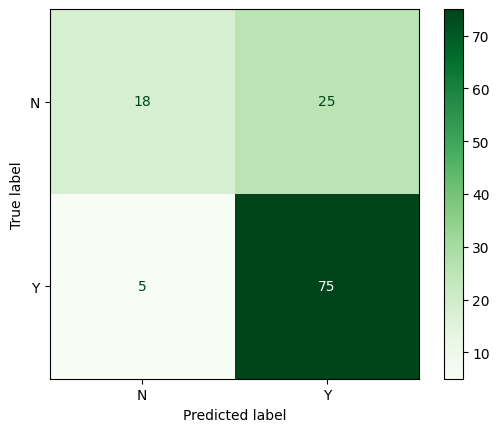

In [112]:
# I will display them in the matrix display 
ConfusionMatrixDisplay.from_predictions(y_test, rf_model_predict, cmap='Greens')

Task 3 4. Describe your results.

| Metric      | Class | Value | Summary                                                                 |
|-------------|-------|-------|-------------------------------------------------------------------------|
| **Precision** | N     | 0.78  | 78% of "No" predictions were correct, but some false positives exist.   |
|             | Y     | 0.75  | 75% of "Yes" predictions were correct, slightly lower than "No".       |
| **Recall**    | N     | 0.42  | Only 42% of actual "No" instances were identified (high false negatives). |
|             | Y     | 0.94  | 94% of actual "Yes" instances were correctly identified.                |
| **F1-Score**  | N     | 0.55  | The model struggles to balance precision and recall for "No" predictions. |
|             | Y     | 0.83  | The model performs well in balancing precision and recall for "Yes".    |

confusion matrix
| Metric              | Count | Description                                                            |
|---------------------|-------|------------------------------------------------------------------------|
| **True Negatives (TN)** | 18    | The model correctly predicted 18 "No" instances.                      |
| **False Positives (FP)** | 25    | The model incorrectly predicted 25 instances as "Yes" when they were actually "No". |
| **False Negatives (FN)** | 5     | The model incorrectly predicted 5 instances as "No" when they were actually "Yes". |
| **True Positives (TP)**  | 75    | The model correctly predicted 75 "Yes" instances.                     |

The overall accuracy of 76% shows that the model is performing well, but the "No" class were not predicted well.
As suggested this might be cause by class imbalance

### Task 4  - Logistic regression (Use your own dataset)

Part A

Identify your own dataset and define the problem


I will use the Titani dataset from kaggle.
The Titanic was a British passenger liner that famously sank on its maiden voyage in 
1912 after hitting an iceberg. Known as "unsinkable," it tragically took the lives of over 1,500 people. 
The disaster remains one of the most infamous maritime tragedies in history.
So I am going to predict which passengers survived the Titanic shipwreck  using the test set 

Task 4 B. Start by creating and evaluating a default logistic regression model using appropriate metrics and a confusion matrix

In [9]:
# I will start by importing my titanic dataset 
df = pd.read_csv("C:/Users/ISHMO_CT/Desktop/projects/Loan_ML/Data/titanic/train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [16]:
# I will start by finding out the shape of my dataframe 
df.shape

(891, 12)

In [15]:
# Do some data cleaning 
print(len(df['PassengerId'].unique()))
print(len(df['Name'].unique()))

891
891


In [6]:
# I will set the passenger id index since I will not use it in creating the model
# Because it is unique throught it might not help in predicting 
df = df.set_index("PassengerId")

In [17]:
# I will drop the name column too. it is also unique through so it might not help me in my model 
df = df.drop(columns="Name")
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,male,35.0,0,0,373450,8.0500,NaN,S


In [18]:
# I will start by spliting the data set into target and feature
target = "Survived"
y = df[target]
X = df.drop(columns=target)


In [19]:
print(X.shape)
print(y.shape)

(891, 10)
(891,)


In [20]:
# split it further to get the train and test set 
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)
# print the percatge to make sure we split it right 
train_percentage = (len(X_train) / len(X)) * 100
test_percentage = (len(X_test) / len(X)) * 100
print(f"Training Set Percentage: {train_percentage:.2f}%")
print(f"Test Set Percentage: {test_percentage:.2f}%")

Training Set Percentage: 79.91%
Test Set Percentage: 20.09%


In [21]:
# Create pipelines for ordinal, numerical and nominal columns  
# I have identified an Ordinal column (Pclass) but it is already numerical so I wont encode it 
# Define the columns
nominal_features = ['Sex', 'Ticket', 'Cabin', 'Embarked']
numerical_features = ['Age', 'SibSp', 'Parch', 'Fare', 'Pclass']

# numerical pipeline
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Norminal pipeline
nominal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value="MISSING")),
    ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# column trnsformer to tranform the data
column_transformer = ColumnTransformer(
    transformers=[
        ('ordinal', numerical_pipeline, numerical_features),
        ('numerical', numerical_pipeline, numerical_features)
    ])

In [22]:
# Now lets create the deafult logisitc model with pipeline
lg_pipeline = Pipeline(steps=[
    ('preprocessor', column_transformer),
    ('lg_classifier', LogisticRegression())
])

In [23]:
# now let me train the model using the Pipeline 
lg_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'SibSp', 'Parch',
                                                   'Fare', 'Pclass']),
                                                 ('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'SibSp', 'Parch',
                                                   'Fare', 'Pclass'])])),
                ('lg_classifier', LogisticRegression())])

Evaluatie the Default logistc model

In [24]:
# The next step is to evaluate the model
# I will start by testing the model with the test data set 
lg_predict = lg_pipeline.predict(X_test)
lg_predict

array([0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0,
       0, 1, 0])

In [25]:
# I will evaluate using classification report usingn the actual test set target values and the predicted values
print(classification_report(y_test, lg_predict))

              precision    recall  f1-score   support

           0       0.72      0.90      0.80       105
           1       0.77      0.50      0.61        74

    accuracy                           0.73       179
   macro avg       0.74      0.70      0.70       179
weighted avg       0.74      0.73      0.72       179



In [26]:
# Then do the confusion matrix to find out the TP, TN, FP, FN
confusion_matrix(y_test, lg_predict)

array([[94, 11],
       [37, 37]])

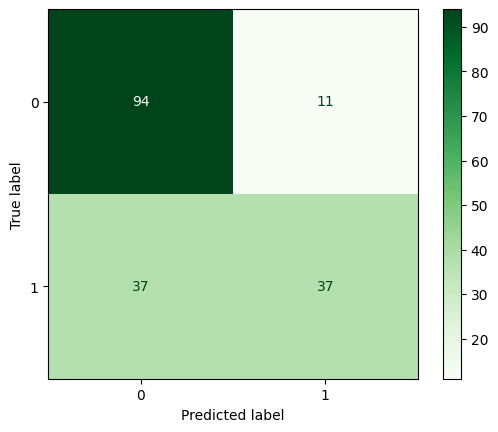

In [27]:
# diaply it in table 
ConfusionMatrixDisplay.from_predictions(y_test, lg_predict, cmap="Greens")

Task 4 part B
Then use GridSearchCV to tune the solver, penalty type and C values (inverse regularization strength), along with trying ‘balanced’ or None for class weight. Be sure to change the default scoring to ‘recall_macro’ when you instantiate the GridSearch.
Your C values should be logarithmic: i.e., [.0001, .001, .01, .1, 1, 10, 100, 1000, 10000]
With elasticnet, remember to tune the ratio of l1 to l2, not C


In [ ]:
# I will starting by defining hyperparameters to be used in the GridSearchCV 
param_grid = {
    'lg_classifier__solver': ['lbfgs', 'liblinear', 'saga'],  # Different solvers
    'lg_classifier__penalty': ['l1', 'l2', 'elasticnet'],  # Penalty types
    'lg_classifier__C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000],  # Logarithmic C values
    'lg_classifier__class_weight': [None, 'balanced'],  # Class weight options
    'lg_classifier__l1_ratio': [0.1, 0.5, 0.7, 0.9],  # Only needed if 'elasticnet' penalty is used
}

In [32]:
# Initialize GridSearchCV with recall_macro scoring
grid_search = GridSearchCV(
    estimator= lg_pipeline,     # model pipeline
    param_grid = param_grid,    #parameter grid
    scoring='recall_macro',     # Optimize recall
    cv=3,                       # 3-fold cross-validation
    verbose=1,                  # Show detailed progress
    n_jobs=-1                   # Use all available CPUs for faster computation
)

In [33]:
# Now I will train my data  
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 648 candidates, totalling 1944 fits


c:\Users\ISHMO_CT\.virtualenvs\Loan_ML-N0COh43c\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
648 fits failed out of a total of 1944.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
216 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\ISHMO_CT\.virtualenvs\Loan_ML-N0COh43c\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\ISHMO_CT\.virtualenvs\Loan_ML-N0COh43c\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ISHMO_CT\.virtualenvs\Loan_ML

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('ordinal',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Age',
                                                                          'SibSp',
                                                                          'Parch',
                                                                          'Fare',
                                                                          'Pclass']),
                                                                        ('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Age',
                                                                          'SibSp',
                                                                          'Parch',
                                                                          'Fare',
                                                                          'Pclass'])])),
                                       (...classifier',
                                        LogisticRegression())]),
             n_jobs=-1,
             param_grid={'lg_classifier__C': [0.0001, 0.001, 0.01, 0.1, 1, 10,
                                              100, 1000, 10000],
                         'lg_classifier__class_weight': [None, 'balanced'],
                         'lg_classifier__l1_ratio': [0.1, 0.5, 0.7, 0.9],
                         'lg_classifier__penalty': ['l1', 'l2', 'elasticnet'],
                         'lg_classifier__solver': ['lbfgs', 'liblinear',
                                                   'saga']},
             scoring='recall_macro', verbose=1)

Task 4 part B, c.
Make sure you have evaluated both the default and the tuned versions using appropriate metrics and a confusion matrix.

In [34]:
# I have already evaluated the default model now I will evaluate the the tuned version
# I will start by getting the best model from the gridsearch 
best_lg_model = grid_search.best_estimator_
best_lg_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'SibSp', 'Parch',
                                                   'Fare', 'Pclass']),
                                                 ('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'SibSp', 'Parch',
                                                   'Fare', 'Pclass'])])),
                ('lg_classifier',
                 LogisticRegression(C=0.1, class_weight='balanced',
                                    l1_ratio=0.1, solver='liblinear'))])

In [36]:
# Use the best model to prediict for the test set
lg_predict_gs = best_lg_model.predict(X_test)
lg_predict_gs

array([0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0,
       1, 1, 1])

In [38]:
# lest use the classification report to evaluate the best model 
# I will use the actual y test (target ) values and the values predicted by the model 
print(classification_report(y_test, lg_predict_gs))

              precision    recall  f1-score   support

           0       0.78      0.74      0.76       105
           1       0.66      0.70      0.68        74

    accuracy                           0.73       179
   macro avg       0.72      0.72      0.72       179
weighted avg       0.73      0.73      0.73       179



In [39]:
# Then I will find out the TP, TN, FP, FN using the matrix
confusion_matrix(y_test, lg_predict_gs)

array([[78, 27],
       [22, 52]])

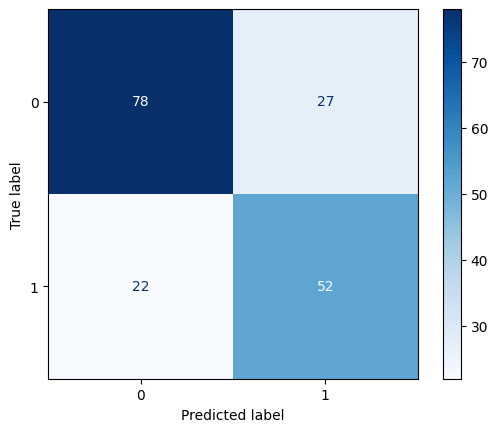

In [41]:
# I will display it in matrix 
ConfusionMatrixDisplay.from_predictions(y_test, lg_predict_gs, cmap="Blues")

In [44]:
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'lg_classifier__C': 0.1, 'lg_classifier__class_weight': 'balanced', 'lg_classifier__l1_ratio': 0.1, 'lg_classifier__penalty': 'l2', 'lg_classifier__solver': 'liblinear'}


TASK 4 B, D, i,In a text cell, address these questions for your logistic regression models:
Which combination of hyperparameters led to the best-tuned model?

for the C it picked out o.1

for the class weight it used balanced

for the l1 ratio it ised 0.1

for penality it used l2 

| Hyperparameter              | Selected Value   |
|----------------------------|------------------|
| `lg_classifier__C`         | 0.1              |
| `lg_classifier__class_weight` | balanced     |
| `lg_classifier__l1_ratio`  | 0.1              |
| `lg_classifier__penalty`   | l2               |
| `lg_classifier__solver`    | liblinear        |


Task 4 part B. ii.Share any two relevant insights from the data. 

In [51]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,male,35.0,0,0,373450,8.0500,NaN,S


In [46]:
# 1. Lets check if the data has imbalanced target values 
print(df['Survived'].value_counts(normalize=True))

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


Yes the data is slightly imbalanced.
The values of 0 are more than the ones of 1.


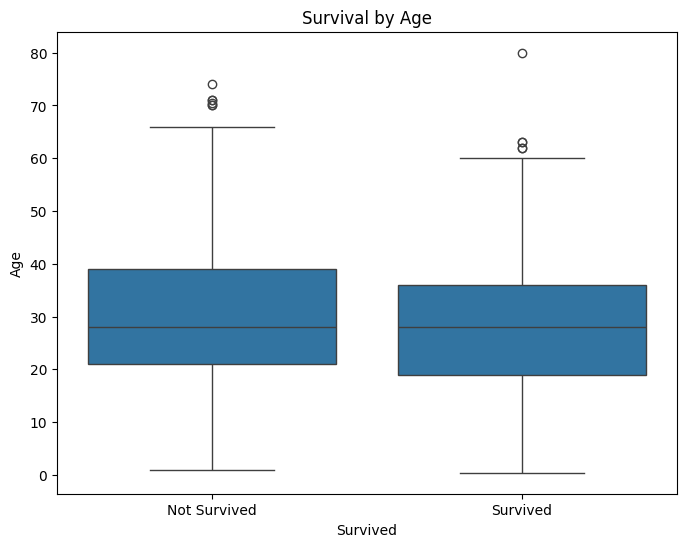

In [54]:
# 2. I will find out the survival rate by age using box plot
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Survived', y='Age')
plt.title('Survival by Age')
plt.xticks([0, 1], ['Not Survived', 'Survived'])
plt.show()



When I took closer look it looks the young ones (below) 35 survived


### Task 5 - Unsupervised learning 

Your stakeholder is a credit card company (dataset attached) that wants to market new credit cards. They have asked you to segment their potential customers to determine how and what kind of cards they should market to each group


In [90]:
# I will start by reading the data 
df = pd.read_csv('C:/Users/ISHMO_CT/Desktop/projects/Loan_ML/Data/cust_seg[Task 5] - cust_seg.csv')

In [91]:
df.head()

,Unnamed: 0,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
0,0,1,41,2,6,19,0.124,1.073,0.0,6.3
1,1,2,47,1,26,100,4.582,8.218,0.0,12.8
2,2,3,33,2,10,57,6.111,5.802,1.0,20.9
3,3,4,29,2,4,19,0.681,0.516,0.0,6.3
4,4,5,47,1,31,253,9.308,8.908,0.0,7.2


Task 5, 1. Use K Means to create various customer segments

In [92]:
# Before I create the segments I will start by cleaning the dataset the I will scale the data
# I will drop two columns Unnamed and Customer Id reason they are unqique thorugt the dataframe so they might not help me 
print(df['Unnamed: 0'].value_counts().sum())
print(df['Customer Id'].value_counts().sum())
print(df.shape)

850
850
(850, 10)


In [93]:
# I will drop them
df = df.drop(['Unnamed: 0', 'Customer Id'], axis=1)

In [94]:
# Still on cleaning code there are NaN values in the dataframe 
# I will need to impute them before scaling them
# Lucky enough they are all numerical columns 
impute = SimpleImputer(strategy='mean')
df_imputed = impute.fit_transform(df)


In [95]:
# I will scale the imputed data
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_imputed)

In [96]:
# Let me view scaled columns in the dataframe
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)
df_scaled.head()

,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
0,0.742915,0.312122,-0.378790,-0.718459,-0.683811,-0.590489,-0.655603,-0.576525
1,1.489490,-0.766349,2.573721,1.384325,1.414474,1.512962,-0.655603,0.391387
2,-0.252518,0.312122,0.211712,0.268032,2.134141,0.801704,1.852167,1.597554
3,-0.750235,0.312122,-0.674041,-0.718459,-0.421643,-0.754467,-0.655603,-0.576525
4,1.489490,-0.766349,3.311849,5.356249,3.638900,1.716094,-0.655603,-0.442507


Text(0, 0.5, 'inertia')

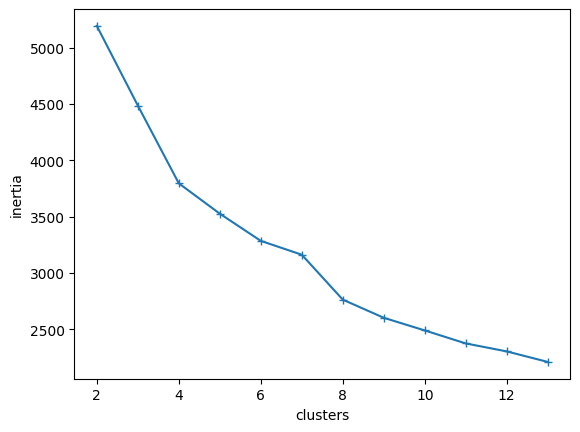

In [97]:
# I will determine the optimal number of cluster using the elbow method 
# kmeans = KMeans(n_clusters=3, random_state=42)

# empty list of innertia 
inertias = []

# loop through k values between 2 to 13 and store the inertias in the list 
for k in range(2, 14):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(df_scaled)
    inertias.append(kmeans.inertia_)

# I will visualize the scores 
plt.plot(range(2, 14), inertias, marker = '+')
plt.xlabel('clusters')
plt.ylabel('inertia')

In [98]:
# The sharpest drop in inertia happens from k=2 to k=5
# After k=5, the curve starts to flatten out
# There’s only minor improvement beyond k=6 or k=7
# Best choice: k = 5 or k = 6 I will use 5 clustrs
kmeans = KMeans(n_clusters=5)
kmeans.fit(df_scaled)

KMeans(n_clusters=5)

In [99]:
# I will disp;ay the labels 
kmeans.labels_

array([1, 2, 0, 1, 3, 2, 1, 1, 1, 2, 4, 1, 1, 0, 4, 1, 1, 1, 2, 1, 1, 1,
       0, 2, 0, 2, 1, 2, 2, 1, 2, 2, 4, 1, 1, 1, 4, 4, 1, 2, 4, 2, 0, 2,
       0, 0, 1, 1, 1, 1, 2, 0, 4, 2, 0, 4, 4, 1, 2, 2, 2, 2, 2, 2, 1, 1,
       2, 4, 1, 4, 1, 1, 2, 1, 1, 1, 1, 1, 2, 2, 2, 0, 2, 1, 2, 1, 1, 1,
       4, 4, 2, 1, 4, 4, 1, 1, 1, 1, 4, 1, 0, 0, 2, 4, 4, 0, 1, 1, 1, 2,
       2, 1, 1, 4, 1, 1, 1, 2, 0, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 2,
       1, 1, 1, 1, 2, 1, 2, 4, 0, 1, 1, 1, 0, 1, 2, 4, 1, 1, 1, 0, 4, 1,
       1, 0, 2, 2, 4, 0, 1, 0, 2, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 4, 1, 0,
       2, 1, 4, 2, 4, 1, 1, 3, 4, 0, 1, 1, 2, 2, 0, 0, 2, 4, 2, 1, 1, 2,
       3, 1, 2, 1, 4, 1, 1, 0, 1, 2, 2, 4, 1, 1, 1, 2, 1, 4, 4, 0, 2, 2,
       4, 2, 1, 1, 1, 1, 2, 1, 0, 2, 1, 1, 0, 1, 2, 1, 2, 4, 0, 1, 1, 1,
       1, 1, 1, 2, 2, 2, 1, 1, 1, 1, 1, 0, 2, 0, 2, 4, 1, 1, 1, 0, 0, 4,
       2, 4, 1, 2, 1, 1, 4, 1, 1, 2, 1, 4, 4, 0, 1, 1, 1, 3, 2, 1, 2, 1,
       2, 1, 2, 2, 1, 1, 1, 0, 1, 1, 4, 1, 4, 2, 2,

In [100]:
# I will display the kmeans inertia we used 
print(kmeans.inertia_)

3497.047245703132


In [101]:
# I will add the labels to the dataframe 
df_scaled['Cluster'] = kmeans.labels_
df_scaled.head()


,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio,Cluster
0,0.742915,0.312122,-0.378790,-0.718459,-0.683811,-0.590489,-0.655603,-0.576525,1
1,1.489490,-0.766349,2.573721,1.384325,1.414474,1.512962,-0.655603,0.391387,2
2,-0.252518,0.312122,0.211712,0.268032,2.134141,0.801704,1.852167,1.597554,0
3,-0.750235,0.312122,-0.674041,-0.718459,-0.421643,-0.754467,-0.655603,-0.576525,1
4,1.489490,-0.766349,3.311849,5.356249,3.638900,1.716094,-0.655603,-0.442507,3


In [102]:
# The last step is to create the customer segments since I have the clusters 
# I will use groupby I will also use the scaled and imputed dataframe
customer_segments = df_scaled.groupby('Cluster').mean()
customer_segments


,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
Cluster,,,,,,,,
0,0.242759,0.290976,0.198687,0.228074,1.093056,1.188282,0.444655,1.616241
1,-0.360020,-0.086835,-0.401339,-0.412945,-0.413238,-0.437514,-0.521040,-0.365209
2,0.956519,-0.047368,1.238530,0.847091,0.114237,0.237956,-0.485691,-0.370865
3,1.464605,0.312122,2.061953,4.156883,4.715468,3.700904,0.812995,0.966178
4,-0.507876,0.078722,-0.790819,-0.485591,-0.221190,-0.270388,1.852167,0.301708


Task 5, 2.Create analytical visualizations that explore statistics for each feature for each cluster.

In [103]:
# plt.figure(figsize=(20, 15))
# sns.pairplot(df_scaled, hue='Cluster', palette="Set2", diag_kind="kde")
# plt.suptitle("Pairwise Scatter Plots by Cluster", y=1.02)  
# plt.show()

# plt.figure(figsize=(12, 8))
# for i, feature in enumerate(df_scaled.columns[:-1]):  # Exclude the 'Cluster' column
#     plt.subplot(3, 3, i + 1)
#     sns.boxplot(x='Cluster', y=feature, data=df_scaled)
#     plt.title(f'Boxplot of {feature} by Cluster')
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(12, 8))
# for i, feature in enumerate(df_scaled.columns[:-1]): 
#     plt.subplot(3, 3, i + 1)
#     sns.violinplot(x='Cluster', y=feature, data=df_scaled)
#     plt.title(f'Violin Plot of {feature} by Cluster')
# plt.tight_layout()
# plt.show()

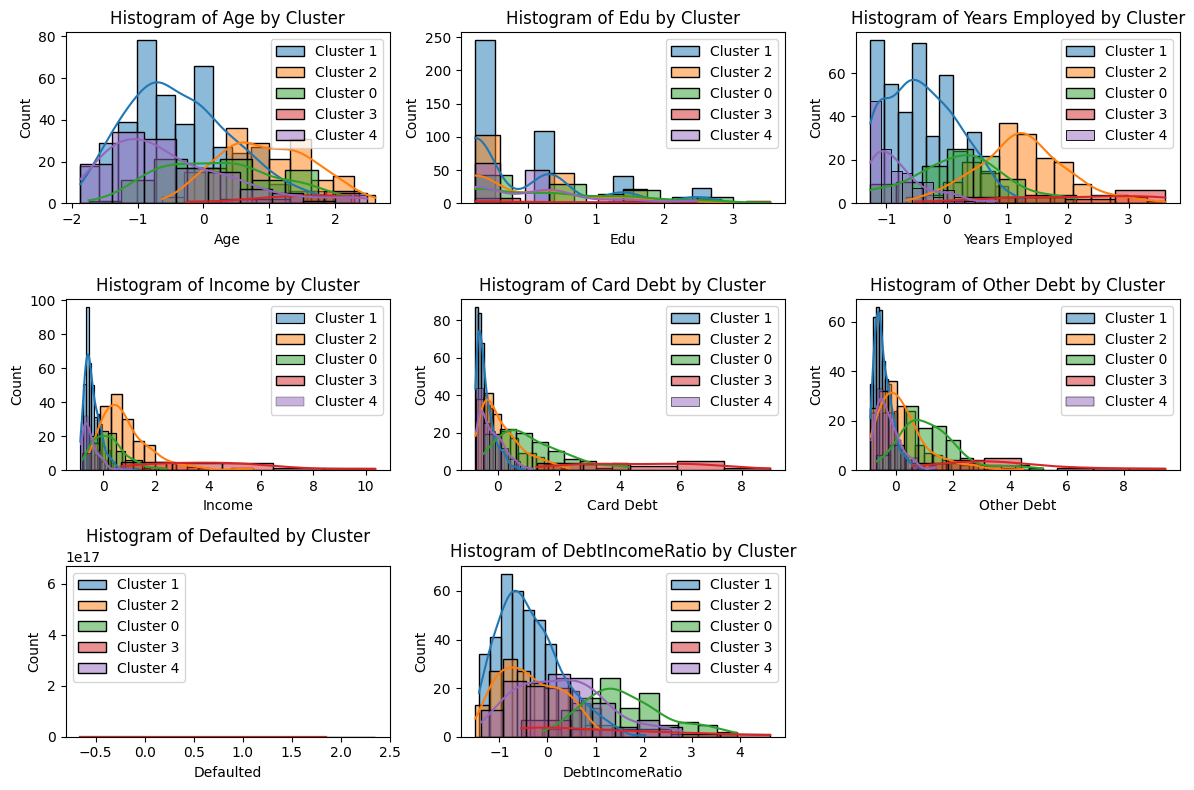

In [104]:
plt.figure(figsize=(12, 8))
for i, feature in enumerate(df_scaled.columns[:-1]): 
    plt.subplot(3, 3, i + 1)
    for cluster in df_scaled['Cluster'].unique():
        sns.histplot(df_scaled[df_scaled['Cluster'] == cluster][feature], kde=True, label=f'Cluster {cluster}')
    plt.title(f'Histogram of {feature} by Cluster')
    plt.legend()
plt.tight_layout()
plt.show()

#### Task 5, 3. Write a description of each cluster based on the visualizations that you created. Do more than describe the numbers;try to see past the numbers and describe what kinds of people are represented by each cluster. Include at least one insight for each cluster.


##### I will describe each cluster with its insight based on group type and risk

### Cluster 0 – The Mid Career, Low Risk Cluster
**Profile:**  
These customers are usually middle-aged and have moderate education. They have worked for a good amount of time, earn a decent income, and have low debt. They also have a balanced debt to income ratio and low risk of not paying their debts.

**Insight:**  
These customers are financially stable and manage their debt well. They are considered "low-risk" for not paying their debts.

---

### Cluster 1 – The Younger, High Risk Cluster
**Profile:**  
Customers in this group are younger and have lower income and education. They also have a high debt to income ratio and a higher risk of not paying their debts.

**Insight:**  
This group may represent young people or those just starting their careers who don’t have financial stability yet. They might be struggling with managing their debt. They could benefit from learning more about money and managing debt.

---

### Cluster 2 – The Highly Educated, High Debt Cluster
**Profile:**  
Customers in this group have higher education levels. They also have a lot of credit card and other types of debt, and a high debt-to-income ratio, even though their income levels vary.

**Insight:**  
This group may include people with advanced degrees, like graduate students or professionals in training (e.g., doctors or lawyers), who are taking on debt now but expect to earn more in the future. Financial institutions may be okay with taking more risk with them because they expect to earn more later.

---

### Cluster 3 – The Conservative, Low Income Cluster
**Profile:**  
This group is made up of older people with lower income and education. They have little debt and a very low risk of not paying their debts.

**Insight:**  
These customers are careful with their spending and may be retirees who live within their means. Even though they earn less, they keep their debt low and are good at managing their finances.

---

### Cluster 4 – The High Income, High Debt Cluster
**Profile:**  
These individuals have higher income and education, but also a lot of credit card and other debt. Their age and years of work experience vary. While they don’t have the highest risk of default, their debt is still very high.

**Insight:**  
These are likely professionals or people with high earnings who have big financial obligations, like mortgages or loans. They may need help planning for the long term to manage their debt better.



#### Task 5, 4.Create one or two recommendations for your stakeholders (the credit card company) regarding how they should market credit cards differently or which cards they should market to each cluster based on your data and insights

#### I will recommend for each cluster

| Cluster                               | Recommendation                                                                                                                                           |
|---------------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Cluster 0 – The Mid-Career Low Risk Cluster** | Offer rewards-based credit cards (e.g., cash back on groceries, gas, and dining) that match their spending behavior.                                   |
| **Cluster 1 – The Younger, High Risk Cluster** | Include features like spending alerts, budgeting tools, and credit score tracking.                                                                     |
| **Cluster 2 – The Highly Educated, High Debt Cluster** | Emphasize future benefits like credit limit increases.                                                                                                   |
| **Cluster 3 – The Conservative, Low-Income Cluster** | Offer basic, no-annual-fee cards with low APR and limited risk features.                                                                                |


### Task 5, 5. Generate another set of segments using hierarchical clustering

In [105]:
# There are two types of hirarchal clustering Agglomerative Hierarchical Clustering (Bottom-up approach) and Divisive Hierarchical Clustering (Top-down approach):
# I will use Agglomerative 
# I will create the clusters first 
agglo_cluster = AgglomerativeClustering(n_clusters=5)
# fit the agglo 
df_scaled['Hierarchal_Cluster'] = agglo_cluster.fit_predict(df_scaled)

In [106]:
# I will display the dataframe with hirachal labels / clusters 
# I will drop the cluster column 
df_scaled = df_scaled.drop(columns='Cluster')
df_scaled.head()

,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio,Hierarchal_Cluster
0,0.742915,0.312122,-0.378790,-0.718459,-0.683811,-0.590489,-0.655603,-0.576525,0
1,1.489490,-0.766349,2.573721,1.384325,1.414474,1.512962,-0.655603,0.391387,1
2,-0.252518,0.312122,0.211712,0.268032,2.134141,0.801704,1.852167,1.597554,4
3,-0.750235,0.312122,-0.674041,-0.718459,-0.421643,-0.754467,-0.655603,-0.576525,0
4,1.489490,-0.766349,3.311849,5.356249,3.638900,1.716094,-0.655603,-0.442507,2


In [108]:
# I will display the hirachal segments 
hierarchal_segments = df_scaled.groupby('Hierarchal_Cluster').mean()
hierarchal_segments

,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
Hierarchal_Cluster,,,,,,,,
0,-0.364534,-0.077255,-0.405440,-0.412423,-0.410562,-0.431895,-0.520122,-0.355212
1,0.954026,-0.039290,1.242603,0.851555,0.110155,0.240624,-0.511959,-0.373908
2,1.464605,0.312122,2.061953,4.156883,4.715468,3.700904,0.812995,0.966178
3,-0.507876,0.078722,-0.790819,-0.485591,-0.221190,-0.270388,1.852167,0.301708
4,0.291555,0.238110,0.240659,0.242836,1.099474,1.173678,0.487399,1.580181


Visualize and describe these clusters.

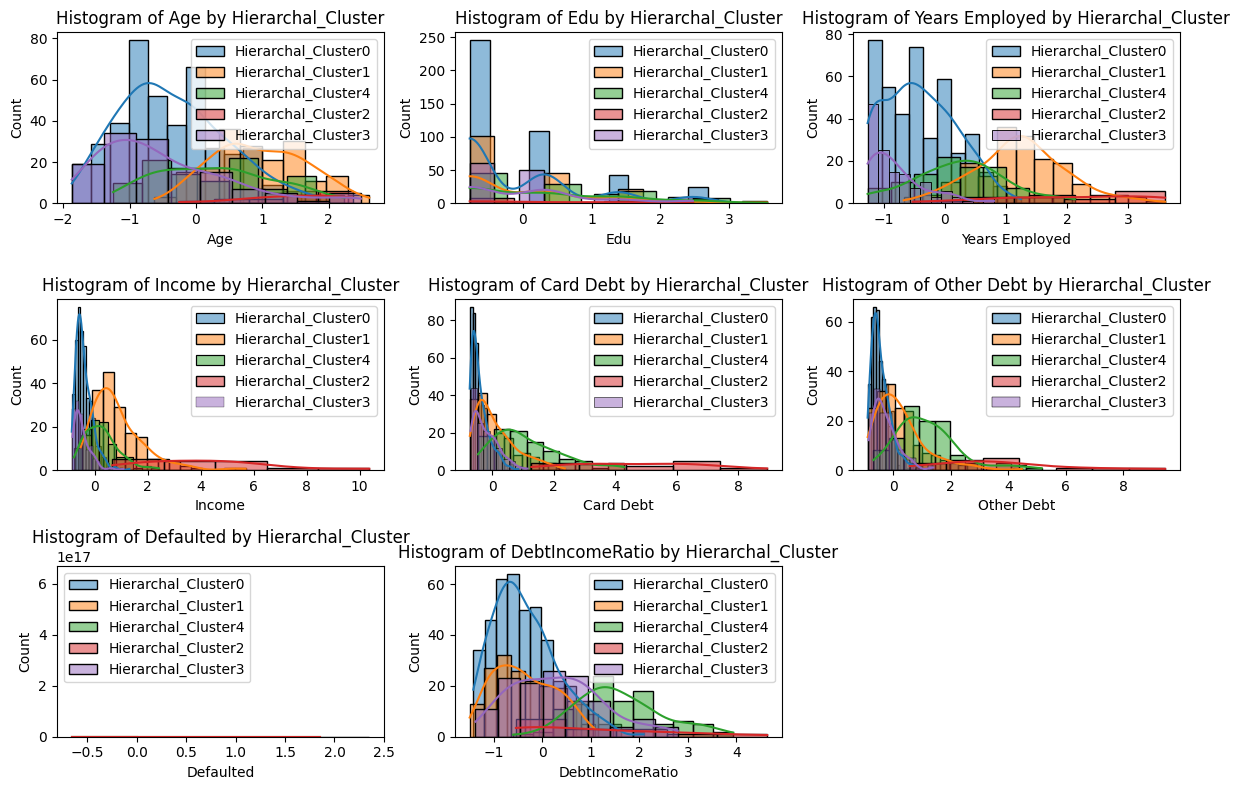

In [110]:
# The best way to visiaulize the hierarchal_segments is by using the dendrogram but I will use s histoplot
plt.figure(figsize=(12, 8))
for i, feature in enumerate(df_scaled.columns[:-1]): 
    plt.subplot(3, 3, i + 1)
    for cluster in df_scaled['Hierarchal_Cluster'].unique():
        sns.histplot(df_scaled[df_scaled['Hierarchal_Cluster'] == cluster][feature], kde=True, label=f'Hierarchal_Cluster{cluster}')
    plt.title(f'Histogram of {feature} by Hierarchal_Cluster')
    plt.legend()
plt.tight_layout()
plt.show()

Describing the clusters

| Hierarchical Cluster   | Profile Summary                                                                                             | Key Insights                                                                                                      |
|------------------------|------------------------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------|
| **Cluster 0** - Low Income, Low Risk, Early Career Individuals | **Age & Years Employed**: Younger individuals with minimal work experience. <br> **Education**: Low to moderate education levels. <br> **Debt Profile**: Low card debt, other debt, and debt-to-income ratio. <br> **Income**: Very low. <br> **Defaulted**: No significant signs of defaulting. | A good target for starter or student credit cards with financial education and small credit limits.             |
| **Cluster 1** - Mid-Career, Moderate Risk Borrowers | **Age & Employment**: Slightly older than Cluster 0, with more years employed. <br> **Education**: Slightly higher education. <br> **Debt Profile**: Moderate levels of card and other debt. <br> **Income**: Also moderate, aligned with mid-career stage. <br> **Debt-to-Income Ratio**: Moderate spread — neither extremely high nor low. | This group could be targeted with rewards or balance transfer cards. They are credit-active and could benefit from perks that match daily spending. |
| **Cluster 3** - Financially Conservative but Lower Income | **Age & Employment**: Range from young to mid-age; varied employment years. <br> **Debt Profile**: Very low across card and other debt. <br> **Income & Default**: Income is low, and no significant defaulting detected. | They may not be aggressive credit users. A no-frills, no-annual-fee credit card with low APR may appeal to this segment. |
| **Cluster 2** - High Risk, High Debt Load Group | **Age & Employment**: Spans a wider range, but includes individuals with several years of employment. <br> **Debt Profile**: High across both card and other debts. <br> **Income**: Also higher — possibly supporting the high borrowing. <br> **Debt-to-Income Ratio**: Highest among all clusters. <br> **Defaulted**: There's a small visible spike suggesting some defaults. | Needs careful credit risk management. Market premium cards with built-in controls (e.g., flexible payments, financial coaching). Include debt relief or consolidation offers. |
| **Cluster 4** - Well-Educated, Higher Earning, Financially Active | **Education**: Higher than average among all clusters. <br> **Income**: On the higher end. <br> **Debt Profile**: Active credit usage but not extreme; card debt is present but manageable. <br> **Years Employed & Age**: Mid to high, indicating experience and stability. | Best fit for premium or travel rewards cards. Emphasize points accumulation, travel perks, and exclusive benefits. |
